## Exploring Patterns in Gun Violence Across Time: Philadelphia Shooting Reports and Washington D.C. Gunfires.

How do gun violence patterns differ between cities across time, and what explains similarites in yearly trends versus daily trends? Or even months?  

### Introduction

Gun violence in major U.S. cities has become a widespread issue but the patterns of this problem can vary across time of day and location. This data analysis  examines how shootings/gunfire in Philly and another large mid-atlantic city, D.C., differ across long-term trends and daily timing. It is often the rhetoric that one city is "safer" than the other, but is that really true? So, if shootings in Philly and D.C. are influenced by national factors, then both cities should exhibit similar increases over the years. Additionally, if the cities are impacted by their local dynamics then they should differ in the timing of shootings.

In simple terms, the cities will show the same patterns over time but different patterns within the day. 

![Philadelphia on Left, D.C. on Right](img/PhlDc.png)

---


### 1. Inspecting Philly Data

In [47]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

import geopandas as gpd

import warnings
warnings.simplefilter('ignore')

In [48]:
shoot_df = pd.read_csv('data/shootings.csv') 

In [49]:
shoot_df.shape

(17516, 25)

In [50]:
shoot_df.columns

Index(['the_geom', 'the_geom_webmercator', 'objectid', 'year', 'dc_key',
       'code', 'date_', 'time', 'race', 'sex', 'age', 'wound',
       'officer_involved', 'offender_injured', 'offender_deceased', 'location',
       'latino', 'point_x', 'point_y', 'dist', 'inside', 'outside', 'fatal',
       'lat', 'lng'],
      dtype='str')

In [51]:
shoot_df.head()

,the_geom,the_geom_webmercator,objectid,year,dc_key,code,date_,time,race,sex,...,location,latino,point_x,point_y,dist,inside,outside,fatal,lat,lng
0,0101000020E61000003CDB07ACFEC752C08841D6A92B03...,0101000020110F0000BA1043EEDCE65FC1DE02479C6993...,1,2021,2.021250e+11,100.0,2021-04-18,06:16:00,W,F,...,4800 BLOCK N HOWARD ST,0.0,-75.124919,40.024770,25.0,1.0,0.0,1.0,40.024770,-75.124919
1,0101000020E61000008CD8ADB931CA52C0C8B91833E402...,0101000020110F000053465B5599EA5FC1B9C82C5A1A93...,2,2021,2.021390e+11,100.0,2021-04-07,14:43:00,B,M,...,2000 BLOCK WINDRIM AVE,0.0,-75.159285,40.022589,39.0,0.0,1.0,1.0,40.022589,-75.159285
2,0101000020E61000008CD8ADB931CA52C0C8B91833E402...,0101000020110F000053465B5599EA5FC1B9C82C5A1A93...,3,2021,2.021390e+11,100.0,2021-04-07,14:43:00,B,M,...,2000 BLOCK WINDRIM AVE,0.0,-75.159285,40.022589,39.0,0.0,1.0,0.0,40.022589,-75.159285
3,0101000020E6100000DC861B6728C852C0800655890300...,0101000020110F000063028BD023E75FC13C7C9D7DE98F...,4,2023,2.023250e+11,100.0,2023-02-16,04:55:00,W,M,...,100 BLOCK E WESTMORLAND ST,1.0,-75.127466,40.000108,25.0,0.0,1.0,1.0,40.000108,-75.127466
4,0101000020E6100000DC861B6728C852C0800655890300...,0101000020110F000063028BD023E75FC13C7C9D7DE98F...,5,2023,2.023390e+11,400.0,2023-02-16,04:55:00,W,F,...,100 BLOCK E WESTMORLAND ST,1.0,-75.127466,40.000108,25.0,0.0,1.0,0.0,40.000108,-75.127466


Here it appears that each row is a shooting incident with corresponding information that provides more detail about each event. There are also geo location duplicate across four columns describing where the shootings occurred.  

In [52]:
shoot_df['the_geom_webmercator']

0        0101000020110F0000BA1043EEDCE65FC1DE02479C6993...
1        0101000020110F000053465B5599EA5FC1B9C82C5A1A93...
2        0101000020110F000053465B5599EA5FC1B9C82C5A1A93...
3        0101000020110F000063028BD023E75FC13C7C9D7DE98F...
4        0101000020110F000063028BD023E75FC13C7C9D7DE98F...
                               ...                        
17511    0101000020110F0000FA682ADFB2F35FC18B57816DD68B...
17512    0101000020110F0000D4398B5B7AE95FC16F2E15EB1D8E...
17513    0101000020110F00004CC0A1F932EA5FC14D9A3D8FD997...
17514    0101000020110F0000DD76C41E9BEA5FC1E919F9484184...
17515    0101000020110F0000DC76D4790EEB5FC129181FF4CC87...
Name: the_geom_webmercator, Length: 17516, dtype: str

In [53]:
shoot_df['the_geom'].head(10)

0    0101000020E61000003CDB07ACFEC752C08841D6A92B03...
1    0101000020E61000008CD8ADB931CA52C0C8B91833E402...
2    0101000020E61000008CD8ADB931CA52C0C8B91833E402...
3    0101000020E6100000DC861B6728C852C0800655890300...
4    0101000020E6100000DC861B6728C852C0800655890300...
5    0101000020E6100000189FB71BFEC452C05038C7950705...
6    0101000020E6100000189FB71BFEC452C05038C7950705...
7    0101000020E6100000189FB71BFEC452C05038C7950705...
8    0101000020E6100000A47AF59B50CD52C0582B874199FC...
9    0101000020E6100000B40380F31ACA52C088BC94106502...
Name: the_geom, dtype: str

---
Seeing that location is present within the data, what do columns in the data represent? Also what are the kinds and range of data captured in dataset?

In [54]:
shoot_df.columns

Index(['the_geom', 'the_geom_webmercator', 'objectid', 'year', 'dc_key',
       'code', 'date_', 'time', 'race', 'sex', 'age', 'wound',
       'officer_involved', 'offender_injured', 'offender_deceased', 'location',
       'latino', 'point_x', 'point_y', 'dist', 'inside', 'outside', 'fatal',
       'lat', 'lng'],
      dtype='str')

Re-examening the dataset, the columns that would best help this analysis are dist (police district), time, and date_. This should provide insight into the locations of the shootings and their temporal attributes.

---

In [55]:
shoot_df['dist'].nunique()

22

In [56]:
shoot_df['dist'].unique()

array([25., 39.,  2., 16., 22., 15., 24., 19., 18., 26., 35., 14., 12.,
        6.,  9., 17.,  1.,  3.,  5.,  7.,  8., nan, 77.])

These are the 22 different districts represented in the dataset.

---

In [57]:
dist_counts = shoot_df['dist'].value_counts()

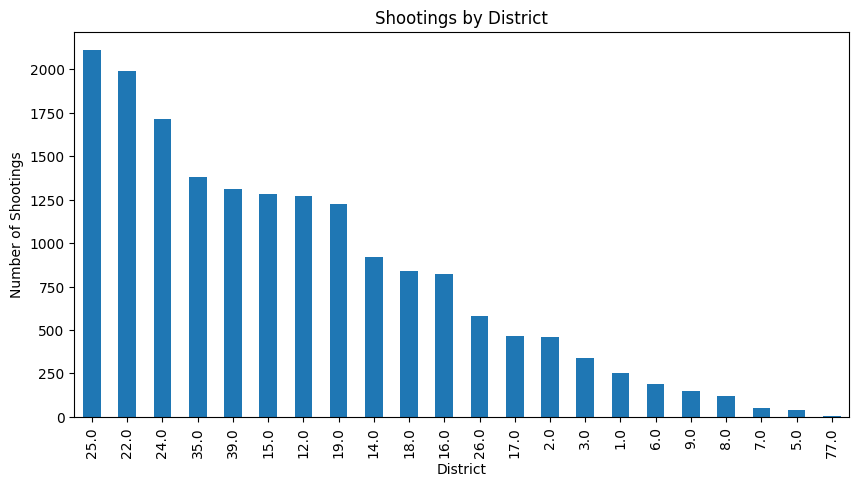

In [58]:
dist_counts.plot(kind='bar', figsize=(10,5))

plt.xlabel('District')
plt.ylabel('Number of Shootings')
plt.title('Shootings by District')

plt.show()

This bar chart displays that the most shootings occur in District 25. 

Since of the begining of 2026, there have already been 7 shooting incidents and 13 shooting victims in District 25 according to https://www.phillypolice.com/districts/25th-district/.

![](img/2026_25dist2.png)
![](img/2026_25dist.png)

In [59]:
districts_df = pd.read_csv('data/Boundaries_District.csv')

In [60]:
districts_df.shape

(22, 14)

In [61]:
districts_df.head()

,OBJECTID,AREA,PERIMETER,DISTRICT_,DISTRICT_ID,DIST_NUM,SUM_AREA,DIST_NUMC,LOCATION,PHONE,DIV_CODE,AREA_SQMI,Shape__Area,Shape__Length
0,343,NaN,69282.588463,16,NaN,16,NaN,16,39th St. & Lancaster Ave.,686-3160,SWPD,1.216700e+08,1.927226e+07,27575.079183
1,344,NaN,33150.154961,17,NaN,17,NaN,17,20th St. & Federal St.,686-3170,SPD,5.786368e+07,9.154950e+06,13179.953350
2,345,NaN,54403.930038,18,NaN,18,NaN,18,55th St. & Pine St.,686-3180,SWPD,9.881929e+07,1.564117e+07,21629.610687
3,346,NaN,51597.051603,35,NaN,35,NaN,35,N. Broad St. & Champlost St.,686-3350,NWPD,1.544309e+08,2.450685e+07,20554.869138
4,347,NaN,58075.014444,39,NaN,39,NaN,39,22nd St. & Hunting Park Ave.,686-3390,NWPD,1.578976e+08,2.503787e+07,23123.580262


In [62]:
districts_df['DIST_NUM'].nunique()

22

In [63]:
districts_df['DIST_NUM'].unique()

array([16, 17, 18, 35, 39,  1,  2,  3, 19, 22, 24, 25, 26, 15, 77,  5,  6,
        7,  8,  9, 12, 14])

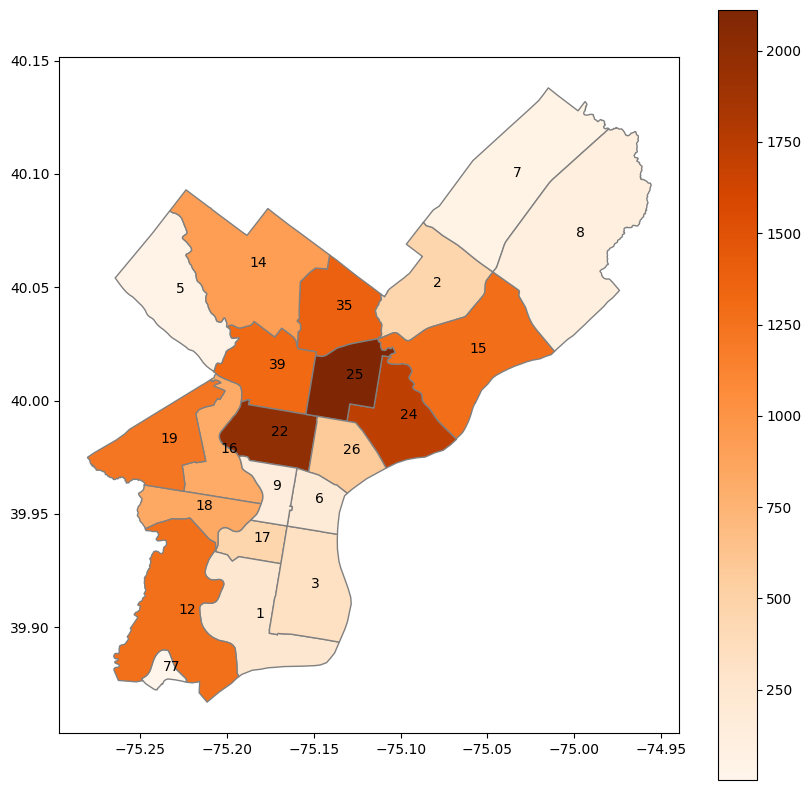

In [64]:
shoot_by_dist=shoot_df['dist'].value_counts()

ppd_dist_gdf = gpd.read_file('data/Boundaries_District.geojson')

ppd_dist_gdf.head()

ppd_dist_gdf['centX']=ppd_dist_gdf.centroid.x
ppd_dist_gdf['centY']=ppd_dist_gdf.centroid.y

ppd_dist_counts_gdf = ppd_dist_gdf.merge(shoot_by_dist, left_on='DIST_NUM', right_index=True) 

ppd_dist_counts_gdf.plot(edgecolor='gray', column='count', figsize=(10,10), 
                         legend=True, cmap='Oranges')

ppd_dist_counts_gdf.apply(lambda r: plt.text(r['centX'], r['centY'], r['DIST_NUM']),axis=1)

plt.show()

In this heat map, the numbered districts with the lighter shades of orange suggest that there are lower numbers of shootings where as the darker shades signify that there are many shootings.

While location can suggest which areas experiences the most gun violence, it is important to look at when these incidents are actually happening. For this, we can look at shootings by the hour which may indicate... 

In [65]:
hour_counts = shoot_df['time'].value_counts(ascending=False).sort_index()
print(hour_counts)

shoot_df['hour'] = pd.to_datetime(shoot_df['time']).dt.hour
hour_counts_grouped = shoot_df['hour'].value_counts().sort_index()
print(hour_counts_grouped)

time
00:00:00    37
00:01:00    18
00:02:00    11
00:03:00    12
00:04:00    16
            ..
23:55:00    16
23:56:00    15
23:57:00    11
23:58:00    20
23:59:00    16
Name: count, Length: 1432, dtype: int64
hour
0.0      915
1.0      974
2.0      733
3.0      580
4.0      394
5.0      305
6.0      269
7.0      215
8.0      257
9.0      324
10.0     429
11.0     525
12.0     679
13.0     549
14.0     646
15.0     695
16.0     746
17.0     837
18.0     970
19.0    1088
20.0    1231
21.0    1379
22.0    1297
23.0    1305
Name: count, dtype: int64


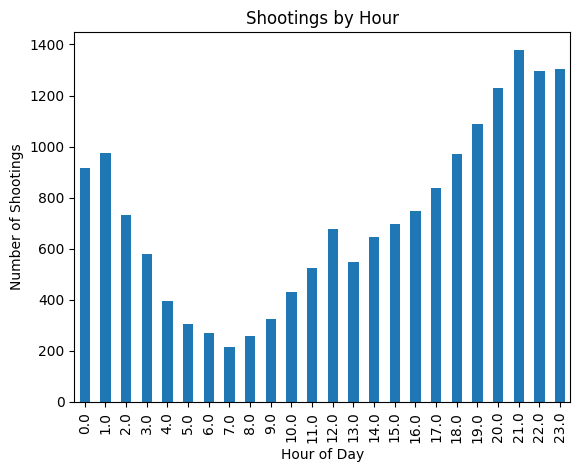

In [66]:
hour_counts_grouped.plot(kind='bar')

plt.xlabel('Hour of Day')
plt.ylabel('Number of Shootings')
plt.title('Shootings by Hour')

plt.show()

Here it is shown that there there is a spike in shootings from 0.0 (12am:am) to 1.0 (1:00am) that gradually decreases as it becomes the morning. Then, shootings spike again after sunset from 19.0 (7:00pm) t0 23.0 (11:00pm) with the most shootings in Philly happening withn the hours of 21.0 (9:00pm) to 22.0 (10:00pm).

These late night shooting counts suggests that most gun violence happens after dark. This may be because people are less likely to commit crimes in broad daylight, or there may be less policing in neighborhoods late at night. Either way, this information describes daily patterns that can be compared to other cities, like D.C., to see whether shootings are more of a night time crime.

In [67]:
shoot_df['year'].value_counts(ascending=False)

year
2021    2342
2022    2269
2020    2259
2023    1672
2019    1473
2018    1447
2016    1342
2015    1294
2017    1265
2024    1112
2025     954
2026      87
Name: count, dtype: int64

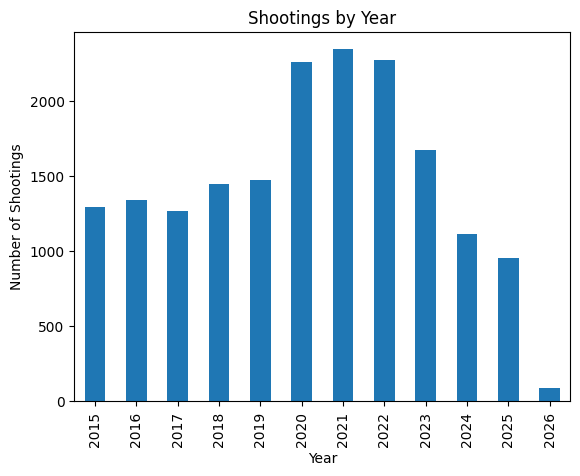

In [68]:
year_counts = shoot_df['year'].value_counts().sort_index()

year_counts.plot(kind='bar')

plt.xlabel('Year')
plt.ylabel('Number of Shootings')
plt.title('Shootings by Year')

plt.show()

This chart depicts the count of shootings from each year, extending from 2015 to 2026. Most visibly, there is a spike in shootings between the yeares of 2020 to 2022. Coincidentally, these were the years in which the United states underwent its nationwide lockdown due to COVID-19. The lockdown was officially declared in mid March of 2020 and ended in May of 2023.

In [69]:
shoot_df['date_'].head()

0    2021-04-18
1    2021-04-07
2    2021-04-07
3    2023-02-16
4    2023-02-16
Name: date_, dtype: str

In [70]:
shoot_df['date_'] = pd.to_datetime(shoot_df['date_'])

month_counts = shoot_df['date_'].dt.month.value_counts().sort_index()
month_counts

date_
1     1288
2     1079
3     1278
4     1325
5     1598
6     1669
7     1783
8     1765
9     1521
10    1542
11    1364
12    1304
Name: count, dtype: int64

In [71]:
phl_2020 = shoot_df[shoot_df['year'] == 2020]
phl_2020.head(5)

,the_geom,the_geom_webmercator,objectid,year,dc_key,code,date_,time,race,sex,...,latino,point_x,point_y,dist,inside,outside,fatal,lat,lng,hour
14,0101000020E6100000F44C4ACF61C752C078293CD592FF...,0101000020110F0000A955FF7BD2E55FC189B78B8A6C8F...,15,2020,2.020241e+11,400.0,2020-11-24,20:00:00,W,F,...,1.0,-75.115345,39.996668,24.0,0.0,1.0,0.0,39.996668,-75.115345,20.0
23,0101000020E6100000F44C4ACF61C752C078293CD592FF...,0101000020110F0000A955FF7BD2E55FC189B78B8A6C8F...,24,2020,2.020241e+11,400.0,2020-10-28,03:45:00,B,M,...,0.0,-75.115345,39.996668,24.0,0.0,1.0,0.0,39.996668,-75.115345,3.0
30,0101000020E6100000746B27B73EC852C0105E9C1480FF...,0101000020110F0000595907B749E75FC1364975C0578F...,31,2020,2.020241e+11,400.0,2020-08-12,23:50:00,W,M,...,1.0,-75.128828,39.996096,24.0,0.0,1.0,0.0,39.996096,-75.128828,23.0
33,0101000020E6100000C4DD2513A5CE52C010B079694BFC...,0101000020110F0000591218A228F25FC13FE1071CCA8B...,34,2020,2.020190e+11,400.0,2020-03-04,12:25:00,B,M,...,0.0,-75.228825,39.971051,19.0,0.0,1.0,0.0,39.971051,-75.228825,12.0
34,0101000020E6100000C4DD2513A5CE52C010B079694BFC...,0101000020110F0000591218A228F25FC13FE1071CCA8B...,35,2020,2.020190e+11,400.0,2020-03-04,12:25:00,B,M,...,0.0,-75.228825,39.971051,19.0,0.0,1.0,0.0,39.971051,-75.228825,12.0


In [72]:
phl_2020['date_'] = pd.to_datetime(phl_2020['date_'])

phl_2020_month_counts = phl_2020['date_'].dt.month.value_counts().sort_index()
phl_2020_month_counts

date_
1     112
2      91
3     143
4     133
5     184
6     205
7     214
8     282
9     229
10    259
11    223
12    184
Name: count, dtype: int64

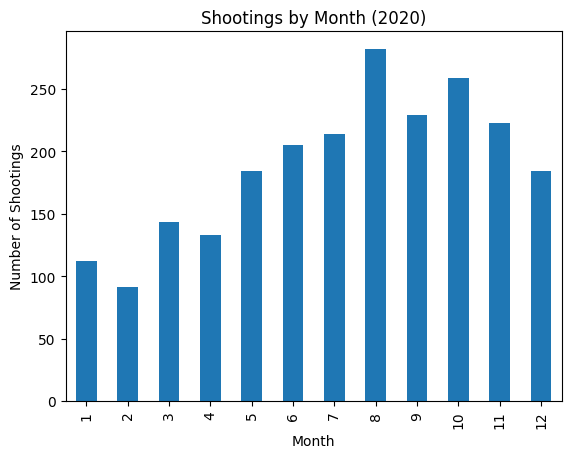

In [73]:
phl_2020_month_counts.plot(kind='bar')

plt.xlabel('Month')
plt.ylabel('Number of Shootings')
plt.title('Shootings by Month (2020)')

plt.show()

In this chart we can see that post March (month 3), which is when the lockdown started, there was an increase in the number of shootings within Philadelphia. This rise in gun incidents after March could indicate that the quarentine had an impact on the amount of shootings that took place in 2020.

"In **March 2020**, the WHO officially **declared the COVID-19 outbreak a pandemic**. In **May 2023**, the WHO declared an **end to the public health emergency** of international concern." (https://www.nm.org/healthbeat/medical-advances/new-therapies-and-drug-trials/covid-19-pandemic-timeline)

---
But to claim that COVID had any influence on shootings, data from 2023 should be examined as it can provide a better look into whether shootings decreased after the lockdown was officially ended.

date_
1     139
2     127
3     149
4     150
5     180
6     173
7     154
8     164
9     122
10    123
11     99
12     92
Name: count, dtype: int64


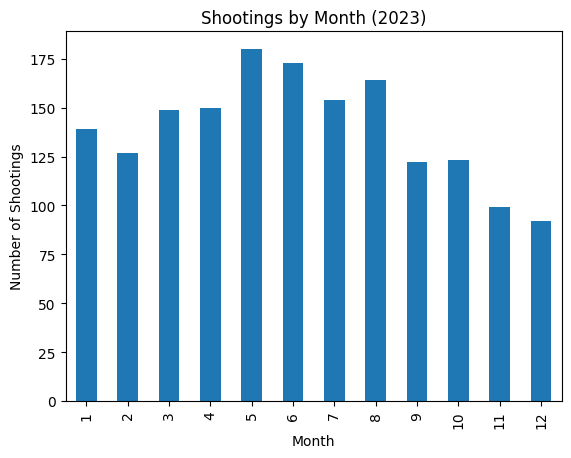

In [74]:
phl_2023 = shoot_df[shoot_df['year'] == 2023]
phl_2023.head(5)

phl_2023['date_'] = pd.to_datetime(phl_2023['date_'])

phl_2023_month_counts = phl_2023['date_'].dt.month.value_counts().sort_index()
print(phl_2023_month_counts)

phl_2023_month_counts.plot(kind='bar')

plt.xlabel('Month')
plt.ylabel('Number of Shootings')
plt.title('Shootings by Month (2023)')

plt.show()

From this chart, it is shown that there was a decrease in the number of shootings in the months after May (month 5).

However, it is important to recognize some caveats. In this case, June (6), July (7), and August (8) all contain higher numbers of shootings. This could be indicative of summer months bringing more shootings rather than the end of the pandemic.

### 2. Inspecting D.C. Data

Does the data from Washington D.C. exhibit the patterns found in Philadelphia?

In [75]:
dc_df = pd.read_csv('data/Shot_Spotter_Gun_Shots.csv') 

In [76]:
dc_df.shape

(88343, 14)

In [77]:
dc_df.columns

Index(['X', 'Y', 'ID', 'TYPE', 'SOURCE', 'DATETIME', 'AUTOACKNOWLEDGED',
       'INDC', 'LATITUDE', 'LONGITUDE', 'GLOBALID', 'CREATED', 'EDITED',
       'OBJECTID'],
      dtype='str')

In [78]:
dc_df.head()

,X,Y,ID,TYPE,SOURCE,DATETIME,AUTOACKNOWLEDGED,INDC,LATITUDE,LONGITUDE,GLOBALID,CREATED,EDITED,OBJECTID
0,-8.571823e+06,4.709646e+06,5D39821,Single_Gunshot,WashingtonDC5D,2014/01/01 06:18:00+00,NaN,NaN,38.916,-77.002,{A5E91420-1F32-4855-9D4E-9812531F96B9},2021/03/10 21:45:53+00,2024/12/02 22:29:03+00,40001
1,-8.571601e+06,4.696349e+06,7D119445,Multiple_Gunshots,WashingtonDC7D,2014/01/01 05:00:10+00,NaN,NaN,38.823,-77.000,{4E43448E-FBA5-49FF-B58B-86B2E3825FC6},2021/03/10 21:45:53+00,2024/12/02 22:29:03+00,40002
2,-8.570822e+06,4.706356e+06,1D55993,Multiple_Gunshots,WashingtonDC1D,2014/01/01 05:00:10+00,NaN,NaN,38.893,-76.993,{7306123A-8090-41B9-8A05-CAAFEB5C7089},2021/03/10 21:45:53+00,2024/12/02 22:29:03+00,40003
3,-8.574495e+06,4.713081e+06,4D34326,Multiple_Gunshots,WashingtonDC4D,2014/01/01 05:00:11+00,NaN,NaN,38.940,-77.026,{CB4CCF70-1552-4A16-BC48-6004EE59F487},2021/03/10 21:45:53+00,2024/12/02 22:29:03+00,40004
4,-8.564699e+06,4.705927e+06,6D102264,Multiple_Gunshots,WashingtonDC6D,2014/01/01 05:00:12+00,NaN,NaN,38.890,-76.938,{EBF9195C-0052-485D-9A4B-ED47A6DCC2F7},2021/03/10 21:45:53+00,2024/12/02 22:29:03+00,40005


In [79]:
dc_df['DATETIME'].nunique()

84257

In [80]:
dc_df['DATETIME'].value_counts(ascending=False).sort_index()

DATETIME
2014/01/01 05:00:02+00    1
2014/01/01 05:00:06+00    1
2014/01/01 05:00:07+00    1
2014/01/01 05:00:10+00    2
2014/01/01 05:00:11+00    1
                         ..
2026/01/01 04:39:00+00    1
2026/01/01 04:42:00+00    1
2026/01/01 04:43:00+00    1
2026/01/01 04:58:00+00    1
2026/01/01 04:59:00+00    1
Name: count, Length: 84257, dtype: int64

In [81]:
dc_df['DATETIME'] = pd.to_datetime(dc_df['DATETIME'])

dc_df['year'] = dc_df['DATETIME'].dt.year

dc_df['year'].value_counts().sort_index(ascending=False)

year
2026       16
2025     4265
2024     6201
2023     8694
2022     7148
2021     8400
2020    13977
2019     6691
2018     4619
2017     4899
2016     5868
2015     8013
2014     9552
Name: count, dtype: int64

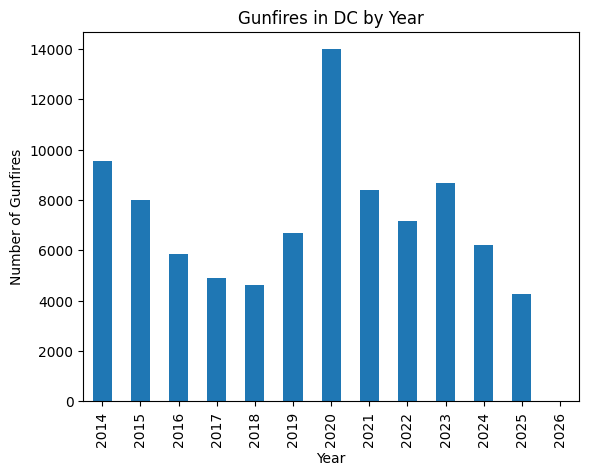

In [82]:
dc_year_counts = dc_df['year'].value_counts().sort_index()

dc_year_counts.plot(kind='bar')

plt.title('Gunfires in DC by Year')
plt.xlabel('Year')
plt.ylabel('Number of Gunfires')

plt.show()

Similar to Philadelphia, Washington D.C. experienced a spike in gunfire in 2020.

In [83]:
dc_df['hour'] = dc_df['DATETIME'].dt.hour

dc_df['hour'].value_counts().sort_index()

hour
0      5514
1      6799
2      7681
3      8911
4     10622
5     11327
6      7456
7      5514
8      3639
9      1981
10     1082
11      743
12      593
13      620
14      668
15      863
16     1082
17     1160
18     1192
19     1490
20     1586
21     1768
22     2457
23     3595
Name: count, dtype: int64

In [84]:
shoot_by_dist=shoot_df['dist'].value_counts()

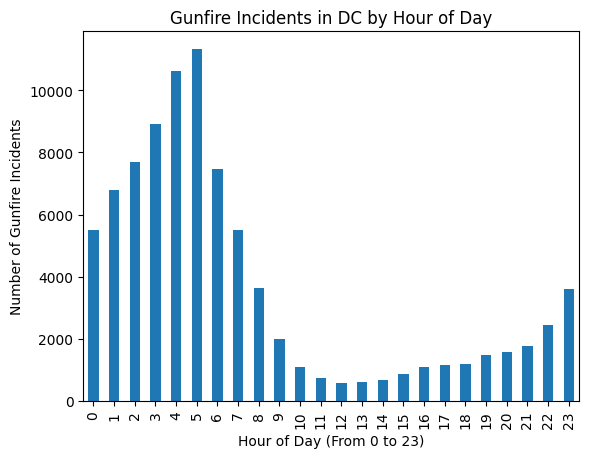

In [85]:
dc_hour_counts = dc_df['hour'].value_counts().sort_index()

dc_hour_counts.plot(kind='bar')

plt.title('Gunfire Incidents in DC by Hour of Day')
plt.xlabel('Hour of Day (From 0 to 23)')
plt.ylabel('Number of Gunfire Incidents')

plt.show()

Now when looking at the hours at which gunfire occurs there are more differences. Like Philly, a majority of gunfire in D.C. happens between the hours of 0-5, or 12:00am to 5:00am. However unlike Philly, there is less gunfire in the evening after sunset from 7:00pm to midnight.

Though, it is important to note that the D.C. data contains more reported gunfires than the shootings detailed in Philadelphia data. Still, the shape of its trends can still tell us a lot.

### 3. Comparing the Cities

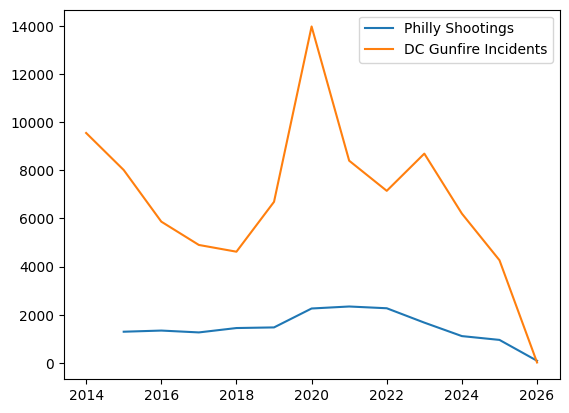

In [86]:
plt.plot(year_counts, label='Philly Shootings')
plt.plot(dc_year_counts, label='DC Gunfire Incidents')
plt.legend()
plt.show()

From this line plot, it is shown that both Philly and DC over the years experienced an increase in gun violence post 2020 and a decrease post 2023. 

---

Examining D.C. in 2020 more thouroughly..

In [87]:
dc_2020 = dc_df[dc_df['year'] == 2020]
dc_2020

,X,Y,ID,TYPE,SOURCE,DATETIME,AUTOACKNOWLEDGED,INDC,LATITUDE,LONGITUDE,GLOBALID,CREATED,EDITED,OBJECTID,year,hour
39265,-8.570376e+06,4.711220e+06,5D132470,Gunshot_or_Firecracker,WashingtonDC5D,2020-01-01 00:25:32+00:00,NaN,NaN,38.927,-76.989,{5600D718-888E-4060-B387-5B9D685189CD},2021/03/10 21:45:53+00,2024/12/02 22:29:03+00,79266,2020,0
39266,-8.573382e+06,4.708502e+06,3D101294,Single_Gunshot,WashingtonDC3D,2020-01-01 00:26:02+00:00,NaN,NaN,38.908,-77.016,{7D949307-3F0A-4238-9F3B-83E840894422},2021/03/10 21:45:53+00,2024/12/02 22:29:03+00,79267,2020,0
39267,-8.574384e+06,4.712794e+06,3D101295,Gunshot_or_Firecracker,WashingtonDC3D,2020-01-01 00:34:16+00:00,NaN,NaN,38.938,-77.025,{BF232ABC-827D-417F-9164-0A65637B1A4D},2021/03/10 21:45:53+00,2024/12/02 22:29:03+00,79268,2020,0
39268,-8.575274e+06,4.710219e+06,3D101318,Multiple_Gunshots,WashingtonDC3D,2020-01-01 01:06:02+00:00,NaN,NaN,38.920,-77.033,{B87125F0-3108-4BD6-B1FE-B65C1B4678AD},2021/03/10 21:45:53+00,2024/12/02 22:29:03+00,79269,2020,1
39269,-8.573048e+06,4.708931e+06,5D132492,Gunshot_or_Firecracker,WashingtonDC5D,2020-01-01 01:11:20+00:00,NaN,NaN,38.911,-77.013,{4B5CB2BC-44C1-42E7-844D-1B9FBE8D73FC},2021/03/10 21:45:53+00,2024/12/02 22:29:03+00,79270,2020,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
53614,-8.567037e+06,4.711937e+06,5D186344,Multiple_Gunshots,WashingtonDC5D,2020-12-31 23:04:34+00:00,True,True,38.932,-76.959,{76C43C49-4D49-4BCC-8B46-3EC0328BAE8F},2021/03/10 21:45:53+00,2024/12/02 22:29:03+00,93615,2020,23
53615,-8.568150e+06,4.712652e+06,5D186348,Gunshot_or_Firecracker,WashingtonDC5D,2020-12-31 23:18:09+00:00,True,True,38.937,-76.969,{5F884C91-7937-487E-B3F3-FF7997B50827},2021/03/10 21:45:53+00,2024/12/02 22:29:03+00,93616,2020,23
53616,-8.568595e+06,4.705928e+06,1D194997,Multiple_Gunshots,WashingtonDC1D,2020-12-31 23:24:29+00:00,False,True,38.890,-76.973,{3CE36EF3-7A8C-446E-B436-360DF8B26052},2021/03/10 21:45:53+00,2024/12/02 22:29:03+00,93617,2020,23
53617,-8.570265e+06,4.708646e+06,1D195000,Multiple_Gunshots,WashingtonDC1D,2020-12-31 23:46:11+00:00,True,True,38.909,-76.988,{4FB37C00-DEDC-4238-91FF-F713EACB71EF},2021/03/10 21:45:53+00,2024/12/02 22:29:03+00,93618,2020,23


In [88]:
dc_2020.columns

Index(['X', 'Y', 'ID', 'TYPE', 'SOURCE', 'DATETIME', 'AUTOACKNOWLEDGED',
       'INDC', 'LATITUDE', 'LONGITUDE', 'GLOBALID', 'CREATED', 'EDITED',
       'OBJECTID', 'year', 'hour'],
      dtype='str')

DATETIME
1      929
2      566
3      740
4      812
5      906
6     1904
7     1842
8     1048
9     1228
10    1442
11    1474
12    1086
Name: count, dtype: int64


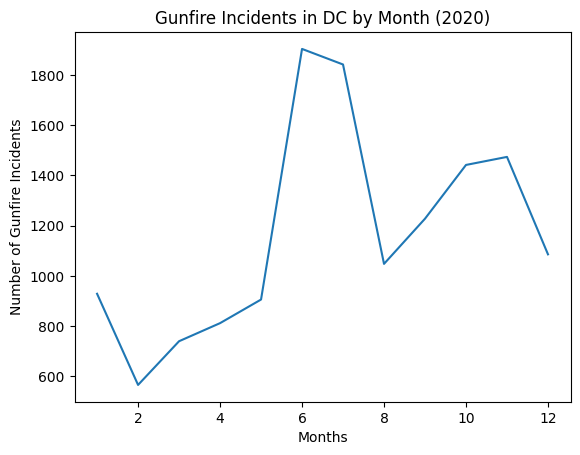

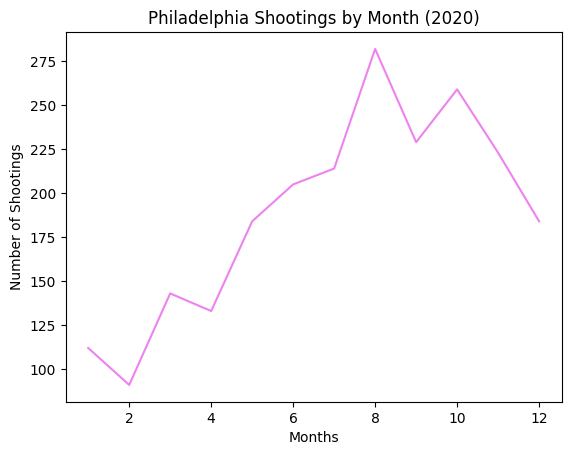

In [89]:
dc_2020['DATETIME'] = pd.to_datetime(dc_2020['DATETIME'])

dc_2020_month_counts = dc_2020['DATETIME'].dt.month.value_counts().sort_index()
print(dc_2020_month_counts)

dc_2020_month_counts.plot(kind='line')
plt.title('Gunfire Incidents in DC by Month (2020)')
plt.xlabel('Months')
plt.ylabel('Number of Gunfire Incidents')

plt.show()

phl_2020_month_counts.plot(kind='line', color= 'violet')

plt.xlabel('Months')
plt.ylabel('Number of Shootings')
plt.title('Philadelphia Shootings by Month (2020)')

plt.show()

Looking at both cities behaviors by month, they both have a high amount of violence post announcement of the lockdown. D.C. experienced significantly more violence in the summer months compared to the winter and spring months (11-4). This is similar to the Philadelphia data which showed a pretty steady increase throughout the summer and decreased in the winter/spring with a second spike from October to November.  

This suggests that the cities had undergone similar shifts in gun violences during the first year of the pandemic.

In [90]:
dc_2020['hour'] = dc_2020['DATETIME'].dt.hour
dc_2020_hours = dc_2020['hour'].value_counts().sort_index()
dc_2020_hours

hour
0     1055
1     1262
2     1391
3     1411
4     1432
5     1493
6     1113
7      809
8      510
9      292
10     165
11     113
12     156
13     112
14     136
15     123
16     153
17     169
18     217
19     251
20     255
21     284
22     454
23     621
Name: count, dtype: int64

In [91]:
phl_2020_hour_counts = phl_2020['time'].value_counts(ascending=False).sort_index()
print(phl_2020_hour_counts)

phl_2020['hour'] = pd.to_datetime(phl_2020['time']).dt.hour
phl_2020_hour_counts_grouped = phl_2020['hour'].value_counts().sort_index()
print(phl_2020_hour_counts_grouped)

time
00:00:00    18
00:01:00     5
00:02:00     2
00:03:00     6
00:04:00     1
            ..
23:55:00     7
23:56:00     1
23:57:00     2
23:58:00     8
23:59:00     4
Name: count, Length: 890, dtype: int64
hour
0.0     147
1.0     116
2.0      56
3.0      54
4.0      52
5.0      23
6.0      25
7.0      26
8.0      21
9.0      26
10.0     35
11.0     58
12.0     64
13.0     76
14.0     95
15.0    109
16.0    128
17.0    109
18.0    134
19.0    152
20.0    200
21.0    195
22.0    164
23.0    179
Name: count, dtype: int64


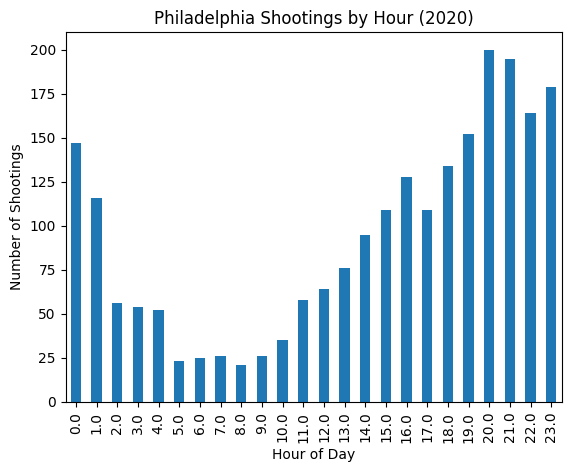

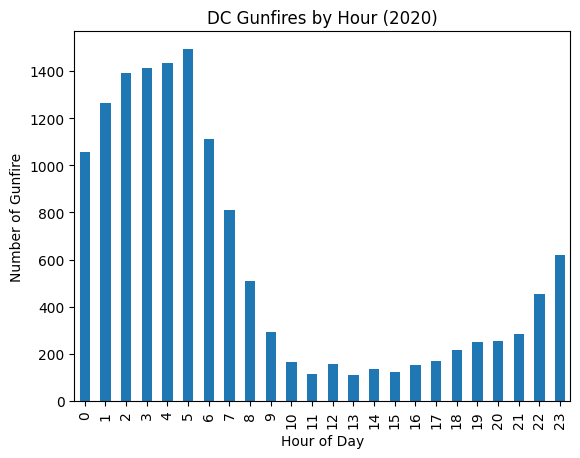

In [92]:
phl_2020_hour_counts_grouped.plot(kind='bar')

plt.xlabel('Hour of Day')
plt.ylabel('Number of Shootings')
plt.title('Philadelphia Shootings by Hour (2020)')

plt.show()

dc_2020_hours.plot(kind='bar')

plt.xlabel('Hour of Day')
plt.ylabel('Number of Gunfire')
plt.title('DC Gunfires by Hour (2020)')
plt.show()

When looking at the hourly behavior of gun violence in both cities, there is a clear difference in what time shootings/gunfire happened during the day. Unlike to the similarities found between the monthly behvaior, this chart suggest that number of gun violence incidents can conjointly be a matter of unique local dynamics and national influence.

(We can still see however that shootings happen more in the night time)

## Conclusion

While Philadelphia and Washington, DC experience similar increases in shootings during key years, their hourly patterns reveal that violence can be shaped by both national and local factors. The findings from this analysis help highlight that  patterns in violence are not just limited to broads trends, they can also be the result of timing and context.